# Revolut account statement – quick view



Pipeline:

1. Load **one** Revolut CSV export

2. Normalize columns + parse types

3. Classify transactions (`type`: expense/income/refund/NA)

4. Categorize expenses via `expense_categories.yml` (keyword → category)

5. Convert amounts to DKK using historical FX (Completed Date)

6. Plot monthly expense spend by category (titles include monthly totals)


In [119]:
import pandas as pd
import numpy as np

# Load exactly ONE CSV export (no merging)
csv_path = 'data/account-statement_2025-11-28_2026-02-07_en-us_a19b3a.csv'
raw = pd.read_csv(csv_path)

print('rows:', len(raw), '| cols:', len(raw.columns))
raw.head()

rows: 158 | cols: 10


,Type,Product,Started Date,Completed Date,Description,Amount,Fee,Currency,State,Balance
0,Deposit,Current,2026-01-02 00:34:03,2026-01-02 00:34:06,Apple Pay deposit by *5126,500.0,0.0,GBP,COMPLETED,500.0
1,Transfer,Current,2026-01-02 00:37:47,2026-01-02 00:37:47,To Flexible Cash Funds,-500.0,0.0,GBP,COMPLETED,0.0
2,Deposit,Current,2026-01-02 01:00:41,2026-01-02 01:00:43,Apple Pay deposit by *5126,2450.0,0.0,GBP,COMPLETED,2450.0
3,Transfer,Current,2026-01-02 01:01:10,2026-01-02 01:01:11,To Flexible Cash Funds,-2450.0,0.0,GBP,COMPLETED,0.0
4,Deposit,Current,2025-11-28 10:07:27,2025-11-28 10:07:28,Apple Pay deposit by *7148,100.0,0.0,DKK,COMPLETED,100.0


In [120]:
import re

def to_snake(name: str) -> str:
    name = str(name).strip()
    name = re.sub(r"[^0-9a-zA-Z]+", "_", name)
    name = re.sub(r"_+", "_", name)
    return name.strip("_").lower()

df = raw.copy()
df.columns = [to_snake(c) for c in df.columns]

# Revolut export: keep original Type in `sub_type`
if 'type' in df.columns and 'sub_type' not in df.columns:
    df = df.rename(columns={'type': 'sub_type'})

# Dates (Completed Date drives FX conversion)
for col in ['completed_date', 'started_date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Numeric columns
for col in ['amount', 'fee', 'balance']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Net amount includes fee (fee is typically positive in Revolut exports)
df['fee'] = pd.to_numeric(df.get('fee', 0), errors='coerce').fillna(0)
df['amount_net'] = pd.to_numeric(df.get('amount', np.nan), errors='coerce') - df['fee'].abs()

# Drop leftovers from older runs / schema changes
df = df.drop(columns=['expense_category', 'conversion_date'], errors='ignore')

df.head()

,sub_type,product,started_date,completed_date,description,amount,fee,currency,state,balance,amount_net
0,Deposit,Current,2026-01-02 00:34:03,2026-01-02 00:34:06,Apple Pay deposit by *5126,500.0,0.0,GBP,COMPLETED,500.0,500.0
1,Transfer,Current,2026-01-02 00:37:47,2026-01-02 00:37:47,To Flexible Cash Funds,-500.0,0.0,GBP,COMPLETED,0.0,-500.0
2,Deposit,Current,2026-01-02 01:00:41,2026-01-02 01:00:43,Apple Pay deposit by *5126,2450.0,0.0,GBP,COMPLETED,2450.0,2450.0
3,Transfer,Current,2026-01-02 01:01:10,2026-01-02 01:01:11,To Flexible Cash Funds,-2450.0,0.0,GBP,COMPLETED,0.0,-2450.0
4,Deposit,Current,2025-11-28 10:07:27,2025-11-28 10:07:28,Apple Pay deposit by *7148,100.0,0.0,DKK,COMPLETED,100.0,100.0


In [121]:
def classify_type(frame: pd.DataFrame) -> pd.Series:
    """Return high-level transaction type: expense/income/refund/NA."""
    out = pd.Series(pd.NA, index=frame.index, dtype='object')

    sub_type = frame.get('sub_type', pd.Series('', index=frame.index, dtype='object')).astype(str).str.strip()
    desc = frame.get('description', pd.Series('', index=frame.index, dtype='object')).astype(str)

    # Expense rule
    out.loc[sub_type.eq('Card Payment')] = 'expense'

    # Income rules (override expense if both ever match)
    is_income = desc.str.contains('BETTERAI LLC', case=False, na=False) | desc.str.contains('paypal', case=False, na=False)
    out.loc[is_income] = 'income'

    # Refund rule: if ANY column contains 'refund' (case-insensitive), mark as refund (overrides everything).
    # Convert to string to make it robust to mixed dtypes.
    has_refund = frame.astype(str).apply(lambda col: col.str.contains('refund', case=False, na=False))
    is_refund = has_refund.any(axis=1)
    out.loc[is_refund] = 'refund'

    if is_refund.any():
        cols_with_refund = has_refund.any(axis=0)
        print('refund rows:', int(is_refund.sum()))
        print('refund appears in columns:', cols_with_refund[cols_with_refund].index.tolist())

    return out

df['type'] = classify_type(df)
df['type'].value_counts(dropna=False)

refund rows: 2
refund appears in columns: ['sub_type']


type
<NA>       81
expense    73
income      2
refund      2
Name: count, dtype: int64

In [ ]:
# Categorize expenses using the YAML mapping (expense_categories.yml)

from processing import categorize_expenses



df = categorize_expenses(df)



is_expense = df['type'].astype(str).str.casefold().eq('expense')

df.loc[is_expense, 'category'].value_counts(dropna=False)


category
Groceries      23
Travel         14
Fuel           11
Ice Hockey      7
Shopping        6
Eat Out         4
Maintenance     2
Bills           2
Other           2
Car service     1
Health          1
Name: count, dtype: int64

In [123]:
# Quick snapshot
display_cols = [
    'completed_date', 'sub_type', 'description', 'currency', 'amount', 'fee', 'amount_net', 'type', 'category'
]
display_cols = [c for c in display_cols if c in df.columns]

print('type counts:')
display(df['type'].value_counts(dropna=False))

print('\nhead:')
df[display_cols].head(10)

type counts:


type
<NA>       81
expense    73
income      2
refund      2
Name: count, dtype: int64


head:


,completed_date,sub_type,description,currency,amount,fee,amount_net,type,category
0,2026-01-02 00:34:06,Deposit,Apple Pay deposit by *5126,GBP,500.00,0.00,500.00,<NA>,<NA>
1,2026-01-02 00:37:47,Transfer,To Flexible Cash Funds,GBP,-500.00,0.00,-500.00,<NA>,<NA>
2,2026-01-02 01:00:43,Deposit,Apple Pay deposit by *5126,GBP,2450.00,0.00,2450.00,<NA>,<NA>
3,2026-01-02 01:01:11,Transfer,To Flexible Cash Funds,GBP,-2450.00,0.00,-2450.00,<NA>,<NA>
4,2025-11-28 10:07:28,Deposit,Apple Pay deposit by *7148,DKK,100.00,0.00,100.00,<NA>,<NA>
5,2025-12-01 10:47:02,Charge,Card Delivery Fee,DKK,0.00,59.99,-59.99,<NA>,<NA>
6,2025-12-10 17:46:02,Deposit,Apple Pay deposit by *7148,DKK,100.00,0.00,100.00,<NA>,<NA>
7,2025-12-18 10:15:55,CARD_CREDIT,Paypal*ordikhani Seyedlar,DKK,24548.03,0.00,24548.03,income,<NA>
8,2025-12-18 17:25:52,Transfer,Revpoints Spare change,DKK,-46.35,0.00,-46.35,<NA>,<NA>
9,2025-12-19 11:56:34,Card Payment,Netto,DKK,-340.73,0.00,-340.73,expense,Groceries


In [124]:
import time
import requests
import pandas as pd
import logging
import numpy as np

logger = logging.getLogger(__name__)

# Convert income/expense/refund amounts to DKK using historical daily rates (ECB via frankfurter.app).
def fx_rate_on_date(
    date: pd.Timestamp,
    from_ccy: str,
    to_ccy: str = 'DKK',
    max_backtrack_days: int = 10,
    _cache: dict = {},
 ):
    """Returns (rate, used_date)."""
    from_ccy = str(from_ccy).upper().strip()
    to_ccy = str(to_ccy).upper().strip()

    if not from_ccy or from_ccy == to_ccy:
        used = pd.Timestamp(date).date() if not pd.isna(date) else None
        return 1.0, used

    if pd.isna(date):
        return None, None

    d = pd.Timestamp(date).date()
    for attempt in range(max_backtrack_days + 1):
        key = (str(d), from_ccy, to_ccy)
        if key in _cache:
            return _cache[key]

        url = f"https://api.frankfurter.app/{d}?from={from_ccy}&to={to_ccy}"
        try:
            r = requests.get(url, timeout=10)
            if r.status_code == 200:
                data = r.json()
                rate = float(data['rates'][to_ccy])
                api_date_str = data.get('date')
                used_date = pd.to_datetime(api_date_str).date() if api_date_str else d
                _cache[key] = (rate, used_date)
                return rate, used_date
        except Exception:
            logger.warning(
                f"Failed to fetch FX rate for {from_ccy}->{to_ccy} on {d} "
                f"(attempt {attempt+1}/{max_backtrack_days+1})"
            )

        # Backtrack one day (ECB doesn't publish weekend/holiday rates)
        d = (pd.Timestamp(d) - pd.Timedelta(days=1)).date()
        time.sleep(0.05)

    return None, None

df = df.copy()
df = df.drop(columns=['conversion_date'], errors='ignore')
df['amount_dkk'] = pd.NA
df['conversion_rate'] = pd.NA

mask = (
    df['type'].isin(['income', 'expense', 'refund'])
    & df.get('amount_net').notna()
    & df.get('currency').notna()
    & df.get('completed_date').notna()
)
if not mask.any():
    print('No rows to convert (income/expense/refund with amount_net/currency/completed_date).')
else:
    ccy = df.loc[mask, 'currency'].astype(str).str.upper().str.strip()
    dt = pd.to_datetime(df.loc[mask, 'completed_date'], errors='coerce').dt.normalize()
    amt = pd.to_numeric(df.loc[mask, 'amount_net'], errors='coerce')

    # Rates: DKK -> 1.0, otherwise fetch per (date, currency) unique pair
    rate = pd.Series(1.0, index=ccy.index, dtype='float')
    need = ccy.ne('DKK') & dt.notna()
    pairs = pd.DataFrame({'dt': dt[need], 'ccy': ccy[need]}).drop_duplicates()

    pair_to_rate = {}
    for r in pairs.itertuples(index=False):
        fx, _used = fx_rate_on_date(r.dt, r.ccy, 'DKK')
        pair_to_rate[(r.dt.date(), r.ccy)] = fx

    rate.loc[need] = [pair_to_rate.get((d.date(), c), np.nan) for d, c in zip(dt[need], ccy[need])]

    df.loc[mask, 'conversion_rate'] = rate
    df.loc[mask, 'amount_dkk'] = amt * rate

# Quick preview
preview_cols = ['completed_date','sub_type','description','currency','amount_net','type','category','conversion_rate','amount_dkk']
preview_cols = [c for c in preview_cols if c in df.columns]
df[preview_cols].head(12)

,completed_date,sub_type,description,currency,amount_net,type,category,conversion_rate,amount_dkk
0,2026-01-02 00:34:06,Deposit,Apple Pay deposit by *5126,GBP,500.00,<NA>,<NA>,<NA>,<NA>
1,2026-01-02 00:37:47,Transfer,To Flexible Cash Funds,GBP,-500.00,<NA>,<NA>,<NA>,<NA>
2,2026-01-02 01:00:43,Deposit,Apple Pay deposit by *5126,GBP,2450.00,<NA>,<NA>,<NA>,<NA>
3,2026-01-02 01:01:11,Transfer,To Flexible Cash Funds,GBP,-2450.00,<NA>,<NA>,<NA>,<NA>
4,2025-11-28 10:07:28,Deposit,Apple Pay deposit by *7148,DKK,100.00,<NA>,<NA>,<NA>,<NA>
5,2025-12-01 10:47:02,Charge,Card Delivery Fee,DKK,-59.99,<NA>,<NA>,<NA>,<NA>
6,2025-12-10 17:46:02,Deposit,Apple Pay deposit by *7148,DKK,100.00,<NA>,<NA>,<NA>,<NA>
7,2025-12-18 10:15:55,CARD_CREDIT,Paypal*ordikhani Seyedlar,DKK,24548.03,income,<NA>,1.0,24548.03
8,2025-12-18 17:25:52,Transfer,Revpoints Spare change,DKK,-46.35,<NA>,<NA>,<NA>,<NA>
9,2025-12-19 11:56:34,Card Payment,Netto,DKK,-340.73,expense,Groceries,1.0,-340.73


In [125]:
# Sanity checks: conversion coverage + totals by type (DKK)
tmp = df.copy()
tmp['amount_dkk'] = pd.to_numeric(tmp.get('amount_dkk'), errors='coerce')

coverage = (
    tmp.assign(converted=tmp['amount_dkk'].notna())
       .groupby(['type','currency'], dropna=False)['converted']
       .agg(rows='count', converted='sum')
       .sort_values(['type','currency'])
 )
coverage

rows  converted
type    currency                 
expense DKK         73         69
income  DKK          1          1
        USD          1          1
refund  DKK          2          2
NaN     DKK         67          0
        GBP          4          0
        USD         10          0

In [126]:
# Optional debug: direct API check (disabled by default)

# import requests
# d = '2026-01-27'
# resp = requests.get(f"https://api.frankfurter.app/{d}?from=USD&to=DKK", timeout=10)
# resp.status_code, resp.json()

In [127]:

# import pandas as pd
# import matplotlib.pyplot as plt

# def get_currency_historical(
#     from_currency: str,
#     to_currency: str,
#     from_date,
#     to_date,
#  ):
#     """Return a DataFrame of daily historical FX rates between two dates (inclusive).

#     Columns:
#     - requested_date: the calendar date requested
#     - used_date: the actual date used by the API (may backtrack to last business day)
#     - rate: to_currency per 1 from_currency
#     - backtracked: whether used_date != requested_date
#     """
#     if from_date is None or to_date is None:
#         raise ValueError('from_date and to_date are required')

#     start = pd.Timestamp(from_date).normalize()
#     end = pd.Timestamp(to_date).normalize()
#     if start > end:
#         raise ValueError(f'from_date must be <= to_date (got {start} > {end})')

#     from_ccy = str(from_currency).upper().strip()
#     to_ccy = str(to_currency).upper().strip()

#     days = pd.date_range(start=start, end=end, freq='D')
#     rows = []
#     for d in days:
#         rate, used_date = fx_rate_on_date(d, from_ccy, to_ccy)
#         rows.append({'requested_date': d.date(), 'used_date': used_date, 'rate': rate})

#     out = pd.DataFrame(rows)
#     out['requested_date'] = pd.to_datetime(out['requested_date'])
#     out['used_date'] = pd.to_datetime(out['used_date'])
#     out['backtracked'] = out['used_date'].dt.date != out['requested_date'].dt.date
#     return out

# # USD -> DKK from 2026-01-01 to today (daily)
# fx_usd_dkk = get_currency_historical(
#     from_currency='USD',
#     to_currency='DKK',
#     from_date='2026-01-22',
#     to_date=pd.Timestamp.today(),
#  )

# # Plot
# fig, ax = plt.subplots(figsize=(10, 4))
# ax.plot(fx_usd_dkk['requested_date'], fx_usd_dkk['rate'], linewidth=1)
# ax.set_title('USD → DKK FX rate (requested date)')
# ax.set_xlabel('Date')
# ax.set_ylabel('DKK per 1 USD')
# ax.grid(True, alpha=0.3)
# plt.show()

# fx_usd_dkk['backtracked'].value_counts(dropna=False)

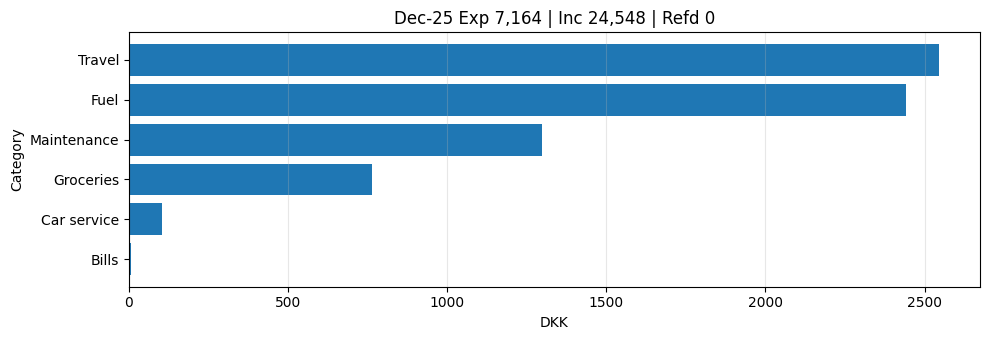

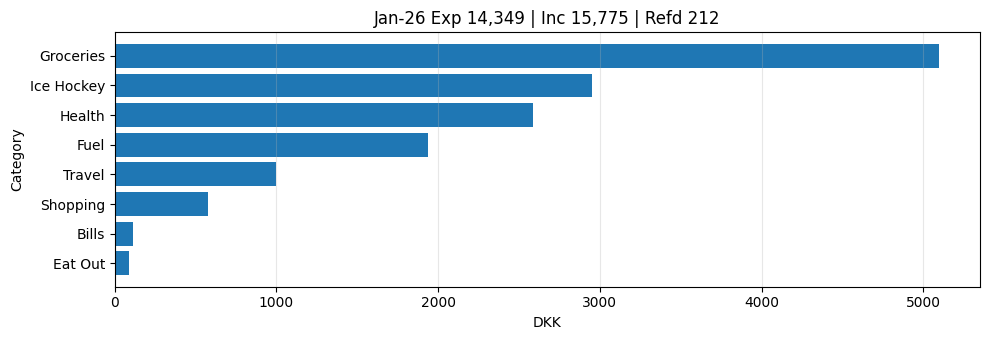

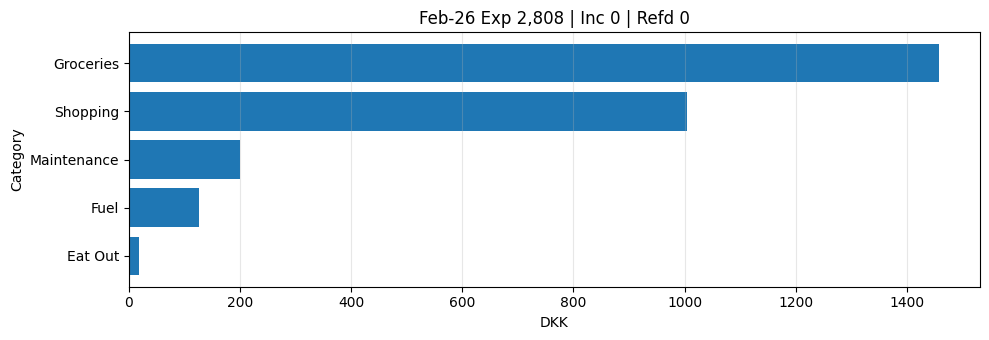

In [131]:
# Monthly expense plots by category (titles include monthly totals)
import matplotlib.pyplot as plt

def fmt_dkk(x: float) -> str:
    return f"{x:,.0f}"

base = df.copy()
base = base[base['completed_date'].notna()].copy()
base['amount_dkk'] = pd.to_numeric(base.get('amount_dkk'), errors='coerce')
base = base[base['amount_dkk'].notna()].copy()
base['month'] = base['completed_date'].dt.to_period('M').astype(str)

types = ['expense', 'income', 'refund']
totals = (
    base[base['type'].isin(types)]
    .assign(value_dkk=lambda x: x['amount_dkk'].abs())
    .groupby(['month', 'type'])['value_dkk']
    .sum()
    .unstack(fill_value=0.0)
 )
for t in types:
    if t not in totals.columns:
        totals[t] = 0.0

exp = base[base['type'].astype(str).str.casefold().eq('expense')].copy()
exp = exp[exp['category'].notna()].copy()
if exp.empty:
    print('No expense rows with non-null category to plot.')
else:
    by_month_cat = (
        exp.assign(spend_dkk=lambda x: x['amount_dkk'].abs())
        .groupby(['month', 'category'])['spend_dkk']
        .sum()
        .reset_index()
     )

    for m in sorted(by_month_cat['month'].unique().tolist()):
        s = (
            by_month_cat[by_month_cat['month'] == m]
            .set_index('category')['spend_dkk']
            .sort_values(ascending=False)
        )
        if s.empty:
            continue

        month_label = pd.Period(m).strftime('%b-%y')
        exp_total = float(totals.loc[m, 'expense']) if m in totals.index else 0.0
        inc_total = float(totals.loc[m, 'income']) if m in totals.index else 0.0
        ref_total = float(totals.loc[m, 'refund']) if m in totals.index else 0.0
        title = (
            f"{month_label} "
            f"Exp {fmt_dkk(exp_total)} | "
            f"Inc {fmt_dkk(inc_total)} | "
            f"Refd {fmt_dkk(ref_total)}"
        )

        fig_h = max(3.5, 0.35 * len(s))
        fig, ax = plt.subplots(figsize=(10, fig_h))
        ax.barh(s.index.astype(str), s.values)
        ax.invert_yaxis()
        ax.set_title(title)
        ax.set_xlabel('DKK')
        ax.set_ylabel('Category')
        ax.set_xlim(left=0)
        ax.grid(True, axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

In [129]:
# List transactions categorized as 'Other' (expenses only)
other_df = df.copy()
other_df = other_df[other_df['type'].astype(str).str.casefold().eq('expense')].copy()
other_df = other_df[other_df['category'].astype(str).eq('Other')].copy()

if other_df.empty:
    print("No expense rows categorized as 'Other'.")
else:
    other_df['amount_dkk'] = pd.to_numeric(other_df.get('amount_dkk'), errors='coerce')
    other_df['spend_dkk'] = other_df['amount_dkk'].abs()

    cols = ['completed_date', 'sub_type', 'description', 'currency', 'amount_net', 'amount_dkk', 'spend_dkk']
    cols = [c for c in cols if c in other_df.columns]

    other_df = other_df.sort_values(['spend_dkk', 'completed_date'], ascending=[False, True])
    display(other_df[cols].head(200))

,completed_date,sub_type,description,currency,amount_net,amount_dkk,spend_dkk
143,NaT,Card Payment,Comfortclic,DKK,-504.0,NaN,NaN
144,NaT,Card Payment,Fafla Mikroverk,DKK,-1205.0,NaN,NaN
